Author: Abdulrahman Altahhan, Feb 2024.

The notebook provides access to a collection of Reinforcement Learning (RL) classes and functions created from scratch using standard Python libraries like NumPy and Matplotlib. These classes and functions are designed for simplicity and to offer insights into how different RL algorithms operate. Please note that using this code for any purpose, including research and commercial applications, requires permission from the author.

# Lesson 3: Grid World Environment Class

In this lesson we cover various grid world environments that are tackled as examples in the accompanying text book available online [here](http://incompleteideas.net/book/RLbook2020.pdf). Please note that we explain the ideas of this topic from a practical perspective and not from a theoretical perspective which is already covered in the textbook.

**Learning outcomes**
1. become familiar with the different types of grid world problems that we will tackle in our units
2. become familiar with the way we assign a reward to an environment
3. be able to execute actions in a grid world and observe the result
4. be able to to visualise a policy and its action-value function

**Reading**:
The accompanying reading of this lesson is **chapter 3** from our text book by Sutton and Barto available online [here](http://incompleteideas.net/book/RLbook2020.pdf). 

In a grid world, we have a set of cells that the agent can move between them inside a box. The agent can move left, right, up and down. We can also allow the agent to move diagonally, but this is uncommon. 

Below we develop our Grid class. We needed to be as efficient as possible, and hence we have chosen to represent each state by its count, where we count from the bottom left corner up to the right top corner, and we start with 0 up to nS-1 where nS is the number of states. This will allow us to streamline the process of accessing and storing a state and will be of at most efficiency. We also deal with actions similarly, i.e. each action of the nA actions is given an index 0..nA-1. For the usual grid, this means 0,1,2,3 for actions left, right, up and down. We represent a 2-d grid by a 1-d array, and so care must be taken on how the agent moves between cells. 

Moving left or right seems easy because we can add or subtract from the *current* state. But when the agent is on the edge of the box, we cannot allow for an action that takes it out of the box. So if the agent is on the far right, we cannot allow it to go further to the right. To account for this issue, we have written a valid() function to validate an action. Moving up and down is similar, but we need to add and subtract a full row, which is how many columns we have in our grid. the valid() function checks for the current state and what would be the next state, and it knows that an agent will overstep the boundary as follows: if s%cols!=0, this means that the agent was not on the left edge and executing a right action (s+a)%cols==0 will take it to the left edge. This means it was on the right edge and wanted to move off this right edge. Other checks are similar. We have also accounted for moving diagonally so the agent will not overstep the boundaries.

We have also accounted for different reward schemes that we might want to use later in other lessons. These are formulated as an array of 4 elements [intermediate, goal1, goal2, cliff] the first reward represents the reward the agent obtains if it is on any intermediate cell. Intermediate cells are non-terminal cells. Goals or terminal states are those that a task would be completed if the agent steps into them. By setting the goals array, we can decide which cells are terminal/goals. As we can see, there are two goals, this will allow us to deal with all the classical problems we will tackle in our RL treatments, but we could have set up more. So, our reward array's second and third elements are for the goals. The last entry is for a cliff. A cliff cell is a special type of non-terminal cell where the agent will emulate falling off a cliff and usually is given a high negative reward and then will be hijacked and put in its start position when it steps into these types of cells. These types of cells are non-terminal in the sense that the agent did not achieve the task when it went to them, but they provoke a reset of the agent position with a large negative reward.

The most important function in our class is the step(a) function. An agent will take a specific action in the environment via this function. Via this function, we return the reward from our environment and a flag (done) indicating whether the task is accomplished. This makes our environment compatible with the classic setup of an OpenAI Gym Atari games, which we deal with towards the end of our RL treatment.

To help you, Abdulrahman recorded a set of videos that covers the chapter.

## Video Lectures for MDP
- [video: MDP](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/ER48PfkfJr1Ck82S9n4SDZkB1dJj3aoTZW88LCy4STKO1A?e=yEpLss)
- [video: Dynamics](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/Eeqp03kBVDxPvPJZByVe-NoB7sySvymdHP64k66J8AtZ_g?e=sJgBqe)
- [video: Returns 1](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/EeqsqeVY8lJJjgVG9f-wxXYBu1JlPFdxPDh_MLfHWouraQ?e=3MAYjH)
- [video: Returns 2](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/EWOLGoq-WM5FhrHu20vBM8QBju2eJo3p90fZbCvOctF9pA?e=2bV3nA)
- [video: Expectation and Sampling](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/Ee14gXvRaDVDirc9gfIU82IBBByAHuj0Lhrgjep4iBHUQA?e=PQe4Mb)
- [video: Bellman Equation for v](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/EVWUbW10cXpEi8vs6qUaSvUBohBWnbsF5x3fjgvUjf1rZw?e=FkcyA6)
- [video: Bellman Equation for q](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/EbDLGDpgacFCvPSOCJPAnIkBfWUWU_UuycDXdPSldaX21w?e=9sUgHc)
- [video: Bellman Optimality Equation 1](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/EZmrPrfyep5LiQkZSSYV0nMB4JqOQplHU6Cbxqkn0ly7dQ?e=518aGx)
- [video: Bellman Optimality Equation 2](https://leeds365-my.sharepoint.com/:v:/g/personal/scsaalt_leeds_ac_uk/ETuJiY2ZboBDox6T4pdM0EoBDDLlFzkjsS2dS2iMYuXAhw?e=byppJl)

You can adjust the video settings in SharePoint (speed up to 1.2 and reduce the noise if necessary)

*Exercise 1*: If you realise there is a missing symbol in the [video: Bellman Equation for v] last equations, do you know what it is and where it has originally come from?

*Exercise 2*: can you derive Bellman Optimality Equation for $q(s,a)$ from first principles?

## $G_t$ Monotonicity for Non-Sparse MDP Rewards
Let us see how the return develop for an MDP with a reward if 1 or -1 for each time step.
To calculate $G_t$ we will go backwards, i.e. we will need to calculate $G_{t+1}$ to be able to calculate $G_t$ due to the incremental form of $G_t$ where we have that $G_t = R_{t+1} + \gamma G_{t+1}$.

- Mathematically, we can prove that $G_t$ is monotonically increasing iff(if and only if) $\frac{R_{t}}{1 - \gamma} >  G_{t}$ $\forall t$ and $G_T=R_T > 0$. 
    - Furthermore, when $R_t=1$ $\forall t$ and $\gamma=.9$ then $G_t$ converges infinitely to 10, i.e. 10 will be an upper bound for $G_t$. 
    - Similarly, when $R_t=1$ $\forall t$ and $\gamma=.09$ then $G_t$ converges infinitely to 100
    - More generally, when $1-\gamma = 1/\beta$ then $ R_t \beta > G_t$ 
- On the other hand, we can prove that $G_t$ is monotonically decreasing iff $\frac{R_{t}}{1 - \gamma} <  G_{t}$.
    - Furthermore, when $R_t=-1$ $\forall t$ and $\gamma=.9$ then $G_t$ converges to -10, i.e. -10 is its lower bound. 
    - More generally, when $1-\gamma = 1/\beta$ then $ R_t \beta < G_t$ 

Below we prove the former and leave the latter for you as a homework.

$G_t = R_{t+1} + \gamma G_{t+1}$

We start by assuming that $G_t$ is strictly monotonically increasing (we dropped the word strictly in th above for readability)

$G_t > G_{t+1} > 0$ $\forall t$ (which entails that $G_T=R_T > 0$ when the horizon is finite, i.e. ends at $t=T$) we substitute by the incremental form of $G_t$

$G_t > G_{t+1} > 0$ $\forall t \implies R_{t+1} + \gamma G_{t+1} >G_{t+1} \implies$  
$R_{t+1} >  G_{t+1} - \gamma G_{t+1} \implies$
$R_{t+1} >  (1 - \gamma) G_{t+1} \implies$

$\frac{R_{t+1}}{1 - \gamma} > G_{t+1}$ ( $\gamma \ne 1$)

The inequality $\frac{R_{t+1}}{1 - \gamma} >  G_{t+1}$ (which also can be written as $\frac{R_{t}}{1 - \gamma} >  G_{t}$) must be satisfied whenever $G_t$ is monotonically increasing, i.e. it is a necessary condition. We can show that this inequality is also a sufficient condition to prove that $G_t$ is monotonically increasing by following the same logic backwards. Similar things can be proven for the non-strictly monotonically increasing case i.e. when $G_t\ge G_{t+1} \ge 0$ $\forall t$.

Now when $R_{t+1}=1$ and $\gamma=.9$ then by substituting these values in the inequality we get that
$\frac{1}{1 - .9} >  G_{t+1} \implies$ $10 > G_{t+1}$ 

The code below confirm this.

In [1]:
G = 0
R = 1
γ = 0.9
T = 100
for t in range(T,0,-1):
    G = R + γ*G
    if t> 70: print('G_',t,'=',G)
    

G_ 100 = 1.0
G_ 99 = 1.9
G_ 98 = 2.71
G_ 97 = 3.439
G_ 96 = 4.0951
G_ 95 = 4.68559
G_ 94 = 5.217031
G_ 93 = 5.6953279000000006
G_ 92 = 6.12579511
G_ 91 = 6.5132155990000005
G_ 90 = 6.861894039100001
G_ 89 = 7.175704635190001
G_ 88 = 7.458134171671
G_ 87 = 7.7123207545039
G_ 86 = 7.94108867905351
G_ 85 = 8.14697981114816
G_ 84 = 8.332281830033345
G_ 83 = 8.49905364703001
G_ 82 = 8.649148282327008
G_ 81 = 8.784233454094307
G_ 80 = 8.905810108684877
G_ 79 = 9.01522909781639
G_ 78 = 9.113706188034751
G_ 77 = 9.202335569231277
G_ 76 = 9.28210201230815
G_ 75 = 9.353891811077334
G_ 74 = 9.4185026299696
G_ 73 = 9.47665236697264
G_ 72 = 9.528987130275377
G_ 71 = 9.57608841724784


## $G_t$ Monotonicity for Sparse MDP Rewards

- For sparse positive end of episode rewards, the above strict inequality is not satisfied since $R_t=0$ $\forall t<T$ and $R_T>0$. In this case, we can show that $G_t \le G_{t+1}$ i.e. $G_t$ it is a monotonically decreasing function although $R_t \ge 0$ $\forall t$. 
- Furthermore, when $\gamma<1$ then $G_t$ is strictly decreasing, i.e.  $G_t < G_{t+1}$, while when $\gamma=1$ then $G_t = R_T G_{t+1}$.
- Furthermore, $G_{t} = \gamma^t R_{T}$.
    - when $R_T=1$ then $G_{t} = \gamma^t$ 
    - when $R_T=-1$ then $G_{t} = -\gamma^t$

To prove the above, we start by our incremental form for the return where we have 
$G_t = R_{t+1} + \gamma G_{t+1}$

Since we have that $R_{t+1} = 0$ $\forall t<T$ then

$G_t = \gamma G_{t+1}$ $\forall t<T$. Therefore, since $\gamma \le 1$ then $G_t \le G_{t+1}$ $\forall t<T$.

$G_{T-1} = \gamma G_{T}$ but $G_{T} = R_{T}$ hence

$G_{T-2} = \gamma G_{T-1}$

$G_{T-2} = \gamma\gamma G_{T}$

$G_{T-2} = \gamma^2 R_{T}$

...
So the return takes the general form 

$G_{t} = \gamma^t R_{T}$

which means that 

$G_{t} = \gamma^t R_{T}$.


This gives us a guidance on the type of behaviour that we expect our agent to develop when we follow one of these rewards regimes (sparse or non-sparse). 

The above suggests that for sparse end of episode reward, decisions near the terminal state(s) has far more importance on the learning than earlier decisions. While for non-sparse positive rewards MDPs, earlier states have higher returns and hence more importance than near terminal states. 

If we want our agent to place more importance on earlier states, near starting state decisions, then we will need to utilise non-sparse (positive or negative) rewards. Positive rewards encourages repeating certain actions that maintain the stream of positive rewards for the agent. AN exmaple will be the pole balancing problem. Negative rewards, encourages the agent to speed up towards ending the episode so that it can minimise the number of negative rewards received.

When we want our agent to place more importance on the decisions near the terminal states, then a sparse reward is more convenient. Sparse rewards are also more suitable for off-line learning as they simplify the learning and analysis of the agent behaviour. Non-sparse rewards suits the online learning on the other hand, because it gives a quick indication of the agent behaviour suitability and hence speed up early population of the value function. 


In [2]:
G = 0
γ = .9 # change to 1 to see the effect
T = 100
for t in range(T,0,-1): # note that if we use a forward loop, our calculations will be all wrong although the code runs
    R=1 if t==T else 0
    G = R + γ*G
    if t>70: print('G_',t,'=',G)
    

G_ 100 = 1.0
G_ 99 = 0.9
G_ 98 = 0.81
G_ 97 = 0.7290000000000001
G_ 96 = 0.6561000000000001
G_ 95 = 0.5904900000000002
G_ 94 = 0.5314410000000002
G_ 93 = 0.47829690000000014
G_ 92 = 0.43046721000000016
G_ 91 = 0.38742048900000015
G_ 90 = 0.34867844010000015
G_ 89 = 0.31381059609000017
G_ 88 = 0.28242953648100017
G_ 87 = 0.25418658283290013
G_ 86 = 0.22876792454961012
G_ 85 = 0.2058911320946491
G_ 84 = 0.1853020188851842
G_ 83 = 0.16677181699666577
G_ 82 = 0.1500946352969992
G_ 81 = 0.13508517176729928
G_ 80 = 0.12157665459056936
G_ 79 = 0.10941898913151243
G_ 78 = 0.0984770902183612
G_ 77 = 0.08862938119652508
G_ 76 = 0.07976644307687257
G_ 75 = 0.07178979876918531
G_ 74 = 0.06461081889226679
G_ 73 = 0.05814973700304011
G_ 72 = 0.0523347633027361
G_ 71 = 0.04710128697246249


Ok, so now we are ready to tackle the practicals, let us get started!

In [3]:
%matplotlib inline

In [4]:
import numpy as np
import random
import time
import math
import io
import sys
import os

from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib import colors
from numpy.random import rand, seed, randint, choice
from random import choices, sample
from tqdm import trange, tqdm

In [5]:
class Grid:
    def __init__(self, gridsize=[6,9], nA=4, s0=3*9, goals=None, Vstar=None):
        self.rows = gridsize[0]
        self.cols = gridsize[1]
        self.nS = self.cols*self.rows # we assume cells IDs go left to right and top down
        self.goals = [self.nS-1, self.nS-1] if goals is None else ([goals[0], goals[0]] if len(goals)==1 else goals)
        self.Vstar = Vstar # optimal state value, needed for some of the environments
        self.s0 = s0
        self.s = s0
        self.trace = [self.s0]
        
        # actions ---------------------------------------------------------------------       
        cols = self.cols
        self.actions_2 = [-1, +1]
        self.actions_4 = [-1, +1, -cols, +cols]     # left, right, down and up
        self.actions_8 = [-1, +1, -cols, +cols, -1-cols, -1+cols, 1-cols, 1+cols] # left-down, left-up, right-down, right-up

        self.nA = nA
        if nA==2: self.actions = self.actions_2
        if nA==4: self.actions = self.actions_4
        if nA==8: self.actions = self.actions_8
        
        # rewards types-----------------------------------------------------------------
        self.nR = 4
        self.rewards = [0, 1, 0, -100] # intermediate, goal1, goal2, cliff
        self.obstacles, self.cliffs = [], [] # lists that will be checked when doing actions
        
        
    def reset(self, withtrace=True):
        self.s = self.s0
        if withtrace: self.trace = [self.s0]
        return self.s_()
    #-----------------------------------------rewards related-------------------------------------------
    def rewards_set(self):
        return np.array(list(set(self.rewards)))
        
    def reward(self):
        stype = self.stype()
        reward = self.rewards[stype]
        if stype==3: self.reset(False)    # s in cliffs
        return reward, 2>=stype>=1        # either at goal1 or goal2
    
    #-----------------------------------------actions related-------------------------------------------
    def invalid(self, s,a):
        cols = self.cols
        # invalid moves are 
        # 1. off grid boundaries
        # 2. off the right edge (last and is for right up and down diagonal actions)
        # 3. off the left edge  (last and is for left  up and down diagonal actions)
        # 4. into an obstacle
        return      not(0<=(s+a)<self.nS) \
                    or (s%cols!=0 and (s+a)%cols==0 and (a==1 or a==cols+1 or a==-cols+1))  \
                    or (s%cols==0 and (s+a)%cols!=0 and (a==-1 or a==cols-1 or a==-cols-1)) \
                    or (s+a) in self.obstacles

    def step(self, a, *args):
        a = self.actions[a]
        if not self.invalid(self.s,a): self.s += a
        
        self.trace.append(self.s)
        reward, done = self.reward()       # must be done in this order for the cliff reset to work properly
        return self.s_(), reward, done, {} # empty dict for compatibility
    
    #-----------------------------------------state related-------------------------------------------
    # useful for inheritance, observation can be a state (index) or a state representation (vector or image)
    def s_(self):
        return self.s
    
    # returns the number of states that are available for the agent to occupy
    def nS_available(self):
        return self.nS - len(self.obstacles)
    
    #-----------------------------------------goals related-------------------------------------------
    # returns the type of the current state (0: intermediate, 1 or 2 at goal1 or goal2, 3:off cliff)
    def stype(self):
        s, goals, cliffs = self.s, self.goals, self.cliffs
        # the order is significant and must not be changed
        return [s not in goals+cliffs, s==goals[0], s==goals[1], s in cliffs].index(True)
    
    def isatgoal(self):
        return self.stype() in [1,2] # either at goal1 or goal2


In a sense, this is the bare-bones class we can readily use to tackle the different problems ahead of us.  Let us test this class to appreciate what it is doing. We have just used a simple state representation that gives each state an index(count). The actions are extremely efficient and boil down to adding or subtracting a number of cell positions depending on the action. If the action is right, then we add 1. If it is left, we subtract 1. When we want the agent to move up, we add one row (number of cols in the grid), and when we want the agent to move down, we subtract cols. Moving diagonally is similar, but we need to combine moving up and left, down and left, up and right, and down and right. Checking if the move is allowed (new state is allowed) as per the agent's current state consists of checking for 4 cases. 
1. the agent is not bypassing outside the grid to boundaries (top or bottom)
2. the agent is not bypassing the right edge of the 2-d grid
3. the agent is not bypassing the left edge of the 2-d grid
4. the agent is not stepping into an obstacle

The set of possible rewards is 4; one for 2 possible goals (terminal states), one for intermediate (non-terminal) states and one special for cliff falling. The class caller can assign one of the special rewards by passing its name, and the setattr() function will handle the rest.

In [6]:
gw = Grid()
print(gw.s)
gw.step(1) # move right
print(gw.s)

27
28


In [7]:
gw = Grid()
def go_far_right():
    gw.s = 0
    for s in range(gw.cols+1):
        gw.step(1)

    print(gw.trace)
    
go_far_right()

[27, 1, 2, 3, 4, 5, 6, 7, 8, 8, 8]


Once the agent hits the right wall it stays there. To see that we adjust the function to overshoot the number of possible cells (cols in this case).

In [8]:
def go_far_right():
    #gw.reset()
    gw.s = 0
    for s in range(gw.cols+1):
        gw.step(1)

    print(gw.trace)
    
go_far_right()

[27, 1, 2, 3, 4, 5, 6, 7, 8, 8, 8, 1, 2, 3, 4, 5, 6, 7, 8, 8, 8]


As we can see once the agent hits the right wall in state 8 it stays there. Note that the new trace is added to the original trace. If you want to create a new trace we can reset the Grid variable gw or we can reset the gw.trace variable.

In [9]:
gw = Grid()
go_far_right()

[27, 1, 2, 3, 4, 5, 6, 7, 8, 8, 8]


## Different Grid Styles
Below we update the Grid class. In all of our treatments we will follow a trend of using the same class name if possible for the child and parent class so that we do not need to deal with different class names when we import theses classes. In this case we have Grid(Grid), which means the new Gris class inherits from the previous(above) Grid class. This allows us to gradually build the capabilities of our classes in a concise and manageable manner.


In [10]:
class Grid(Grid):
    def __init__(self, reward='',  style='', **kw):
        super().__init__(**kw)
    
        # explicit rewards for[intermediate,goal0,goal1, cliff] states
        self.reward_    = [0,    1,   0, -100] # this is the default value for the rewards
        self.cliffwalk  = [-1,  -1,  -1, -100]
        self.randwalk   = [ 0,   0,   1,    0]
        self.randwalk_  = [ 0,  -1,   1,    0]
        self.reward0    = [-1,   0,   0,   -1]
        self.reward_1   = [-1,  -1,  -1,   -1]
        self.reward1    = [-1,   1,   1,   -1]
        self.reward10   = [-1,  10,  10,   -1]
        self.reward100  = [-1, 100, 100,   -1]
        

        if reward: self.rewards  = getattr(self, reward)
        self.style = style
        
        # accommodating grids styles -------------------------------------------------------------
        self.X, self.Y = None, None
        self.Obstacles = self.Cliffs = 0 # np arrays for display only, related to self.obstacles, self.cliffs
        self.wind = [0]*10               # [0,0,0,0,0,0,0,0,0,0]
        
        if self.style=='cliff':
            self.Cliffs = None           # for displaying only, to be filled when render() is called
            self.cliffs = list(range(1,self.cols-1))
            
        elif self.style=='maze':
            self.Obstacles = None        # for displaying only, to be filled when render() is called
            rows = self.rows
            cols = self.cols
            midc = int(cols/2)
            obstacles1 = list(range(2+2*cols, 2+(rows-1)*cols, cols))    # set of vertical obstacles near the start
            obstacles2 = list(range(5+cols, 2*cols-3))                   # set of horizontal obstacles
            obstacles3 = list(range(-2+4*cols,-2+(rows+1)*cols, cols))   # set of vertical obstacles near the end
            self.obstacles = obstacles1 + obstacles2 + obstacles3        # concatenate them all 

        # upward winds intensity for each column
        elif self.style=='windy':
            self.wind = [0,0,0,1,1,1,2,2,1,0] # as in example 6.5 of the book
    
    # override the step() function so that it can deal with wind
    def step(self, a, *args):
        a = self.actions[a]
        if not self.invalid(self.s,a): self.s += a
        
        if self.style=='windy':
            maxwind = self.wind[self.s%self.cols]
            for wind in range(maxwind, 0, -1): # we need to try apply all the wind or at least part of it
                if not self.invalid(self.s, wind*self.cols): self.s += wind*self.cols; break
        
        self.trace.append(self.s)
        reward, done = self.reward()       # must be done in this order for the cliff reset to work properly
        return self.s_(), reward, done, {} # empty dict for compatibility


In [11]:
wind = [0]*10
wind

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

There are a few points to realise in the above class. First, The getattr(self, reward) function allows us to pass a string to the class setter ex. Grid(reward='cliffwalk') and then python will search and return a corresponding attribute or function with the same name ex. self.cliffwalk. This gives us the flexibility to pick from a set of ready-made reward schemes we can choose from via passing their names. 

In addition, the class accounts for different 'style's of environments, such as the 'maze', the 'cliff' and the 'windy' environments. Each one of these styles will have a specific layout in terms of the number of cells and where the goals are. We will demo each to appreciate how they look and how the agent will behave inside them.
Note that the way we structured the obstacles in the maze allows us to change the maze size while keeping the overall structure. This will be useful when we tackle planning algorithms.

Finally, due to the wind adding to the displacement of the robot, we had to override the step(a) function. The function checks the validity of an action and then attempts to add as much of the wind displacement as the grid boundaries allow.

## Visualising the Grid

Ok, dealing with the bare minimum grid without visualisation makes it difficult to observe the behaviour of an agent. Now we add useful set of visualisation routines to make this possible. 

This is will add an overhead so we try to minimise it by only initialising and calling when a render() function is called. 

Below we show an animation example which is based on what we can do in a notebook in contrast with a python standalone code.

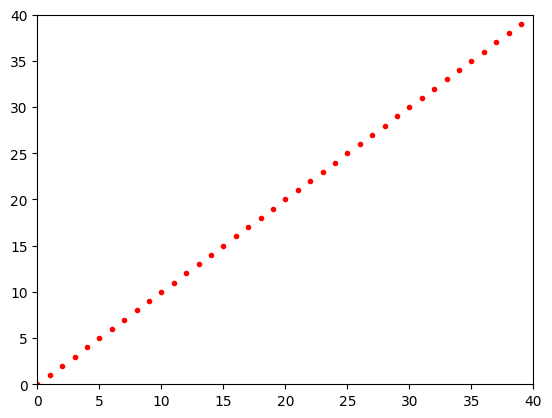

In [12]:
n = 40
ax0 = plt.subplot()
ax0.set_xlim(0, n)
ax0.set_ylim(0, n)
# plt.gcf().set_size_inches(15, 3)

for i in range(n):
    print(i)
    plt.sca(ax0)
    plt.plot(i, i,'r.')
    clear_output(wait=True)
    plt.show()

In [13]:
np.random.rand(3, 5)

array([[0.40633878, 0.39972485, 0.54539109, 0.64510477, 0.98501203],
       [0.74032492, 0.22798293, 0.85613785, 0.43597972, 0.06920562],
       [0.92643802, 0.62985293, 0.55191132, 0.52340502, 0.17125704]])

In [14]:
class Grid(Grid):
    def __init__(self, pause=0, figsize=None, **kw):
        super().__init__(**kw)
        
        self.figsize = figsize # desired figure size        
        self.fig = None        # figure handle, may have several subplots        
        self.ax0 = None        # Grid subplot handle
        
        self.pause = pause     # pause to slow animaiton
        self.arrows = None     # policy arrows (direction of action with max value)
        
        # assuming env is not dynamic, otherwise should be moved to render() near self.to_pos(self.s)
        self.start = self.to_pos(self.s0)         
        self.goal1 = self.to_pos(self.goals[0])
        self.goal2 = self.to_pos(self.goals[1])
        self.cmap = colors.ListedColormap(['w', 'darkgray'])

    # state representation function that converts 1-d list of state representation into a 2-d coordinates
    def to_pos(self, s):
        return [s%self.cols + 1, s//self.cols + 1]

    #------------------------------------------initialise------------------------------------------------- 
    def init_cells(self, cells): 
        Cells = np.zeros((self.rows+1, self.cols+1),  dtype=bool)
        Cells[0,0] = True # to populate for drawing 
        poses = self.to_pos(np.array(cells))
        Cells[poses[1], poses[0]] = True
        return Cells[1:,1:]
    
    #------------------------------------------render ✍️-------------------------------------------------
    # this function is to protect render() called twice for Gridi
    def render(self, **kw):
        self.render__(**kw)

    # we have placed most of the render overhead in the render() function to keep the rest efficient.
    # this funciton must not be called directly instead render() is to be called
    def render__(self, underhood='', pause=None, label='', subplot=131, large=False, 
               animate=True, image=False, saveimg=False,  **kw):
        
        if self.figsize is None:
            if   self.rows==1:             self.figsize = (15,.5) 
            elif underhood=='Q':           self.figsize = (20, 10)
            elif underhood=='V' and large: self.figsize = (30, 25)
            else:                          self.figsize = (17, 3)
        if image: self.figsize = (17, 3) # changing the default figure size is dissallowed for games

        if self.fig is None: self.fig = plt.figure(1)
        #if self.ax0 is None: self.ax0 = plt.subplot(subplot)
        plt.gcf().set_size_inches(self.figsize[0], self.figsize[1])
            
        #if   animate: self.ax0 = plt.subplot(subplot)
        #elif image:   plt.cla() 
        self.ax0 = plt.subplot(subplot)
        if image and not animate: plt.cla()
        
        
        # get hooks for self properties
        rows, cols = self.rows, self.cols
        pos, start, goal1, goal2 = self.to_pos(self.s), self.start, self.goal1, self.goal2
        
        pause = self.pause if pause is None else pause
        
        # a set of properties for the grid subplot
        
        prop = {'xticks': np.linspace(0, cols, cols+1),     'xticklabels':[],
                'yticks': np.linspace(0, rows, rows+1)+.01, 'yticklabels':[],
                'xlim':(0, cols), 'ylim':(0, rows), 'xlabel': label} # useful info
        self.ax0.update(prop)
        self.ax0.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
        if self.style not in ['maze', 'cliff']: self.ax0.grid(True)

        # robot visuals :-)
        mrgn = .5
        eyes = '˚-˚' if underhood!='Q' else '' 
        body = 'ro'  if underhood!='Q' else 'co'
        
        # plot goals and start state
        for (x,y), s in zip([goal1, goal2, start], ['G', 'G', 'S']):
            self.ax0.text(x-mrgn, y-mrgn, s, fontsize=14)
        
        # plot robot
        self.ax0.text(pos[0]-mrgn-.2, pos[1]-mrgn-.15, eyes, fontsize=10)
        self.ax0.plot(pos[0]-mrgn,    pos[1]-mrgn,     body, markersize=15) 
        #self.ax0.plot(pos, body, markersize=15) # this causes the body not be up to date in later lessons

        # to reduce overhead, pre-store coordinates in the grid only when render is needed
        if self.X is None: 
            self.X, self.Y = np.array(self.to_pos(np.arange(self.nS))) 
            self.Ox, self.Oy = np.arange(cols+1), np.arange(rows+1)

        # underhood obstacles and a cliffs
        if self.style=='maze':  
            if self.Obstacles is None: self.Obstacles = self.init_cells(self.obstacles)
            self.ax0.pcolormesh(self.Ox, self.Oy, self.Obstacles, edgecolors='lightgray', cmap=self.cmap)
        
        if self.style=='cliff': 
            if self.Cliffs is None: self.Cliffs = self.init_cells(self.cliffs)
            self.ax0.pcolormesh(self.Ox, self.Oy, self.Cliffs, edgecolors='lightgray', cmap=self.cmap)

        # this means that the user wants to draw the policy arrows (actions)
        if 'Q' in kw and underhood=='': underhood='maxQ'
        
        # a placeholder function for extra rendering jobs
        render_ = getattr(self, 'render_'+ underhood)(**kw)
        # windy style needs a bespoke rendering
        if self.style =='windy': self.render_windy()

        if image: self.render_image(saveimg=saveimg)
            
        # to animate clear and plot the Grid
        if animate: clear_output(wait=True); plt.show(); time.sleep(pause)
        #else: plt.subplot(subplot)
    
    #-------------------------helper functions for rendering policies and value functions---------------------
    def render_(self, **kw):
        pass # a placeholder for a another drawing if needed
    
    def render_image(self, **kw):
        pass # a placeholder for capturing and saving Grid as images
    
    # renders all states numbers' reprsentation on the grid
    def render_states(self, **kw):
        X,Y  = self.X, self.Y
        for s in range(self.nS): 
            self.ax0.text(X[s]-.5,Y[s]-.5, s, fontsize=13, color='g')


Note that we are moving from 1-d list of states to a 2-d set of coordinates. We use the modulus % and the floor division operators to achieve this. Both are built-in operators and very efficient. The function to_pos() convert a state into its correspondent position coordinates. 

The render function does all the heavy lifting of visualising the environment and the agent's current state s. It basically renders a 2-d grid as per the dimension of the grid along the side with the agent and any obstacles (which block the agent pathway) or cliff cells (which cause the agent to reinitialise its position to state s0). We also call a placeholder function render_(), which will be called to render further info. such as the states' representation in the grid, as we will see next.

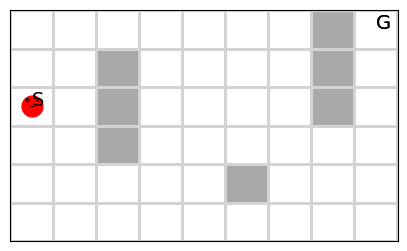

In [15]:
gw = Grid(style='maze')
gw.render()

To see the internal state representation that we use in our grid world we can render it  as follows

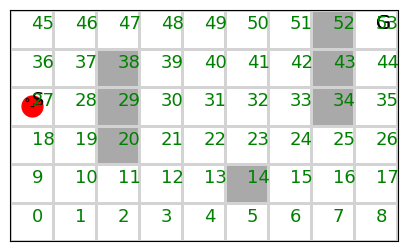

In [16]:
gw.render(underhood='states')

## Animating the Grid
Grid animation is very easy thanks to the render function which take care of setting the scene and clearing the output. Below we show a simple function that achieve this.

In [17]:
def animate_right(gw=Grid(), pause=0):
    gw.s=gw.s0 # reset the agent position
    # let us go right
    for s in range(5):
        gw.step(1)
        gw.render(pause=pause)

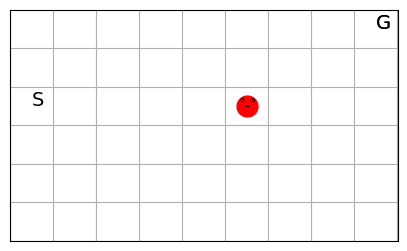

In [18]:
animate_right()

In [19]:
def scan(env, animate=True, pause=0):
    env.s = 0 # env.s0 # reset the agent position

    # scan the whole env
    for s in range(env.s, env.nS):#env.s0,env.s0+1):
        if s in env.obstacles: continue
        for a in range(gw.nA):
            env.s = s
            env.render(animate=animate, pause=pause)
            env.step(a)
            env.render(animate=animate, pause=pause)
        env.s = s
        #plt.pause(.5)

In [20]:
# %time scan(gw)

In [21]:
def wander(gw, animate=True, pause=0):
    gw.s=gw.s0 # reset the agent position
    
    # let us go right
    for s in range(gw.cols):
        gw.step(1)
        gw.render(animate=animate, pause=pause)
    
    # let us go left
    for s in range(gw.rows):
        gw.step(0)
        gw.render(animate=animate, pause=pause)

    # scan the whole env
    for s in range(gw.s,gw.nS):#gw.s0,gw.s0+1):
        if s in gw.obstacles: continue
        for a in range(gw.nA):
            gw.s = s
            gw.render(animate=animate, pause=pause)
            gw.step(a)
            gw.render(animate=animate, pause=pause)
        gw.s = s
        #plt.pause(.5)

In [22]:
# %time wander(Grid())

## Visualising the a Policy on a Grid

Next we further add more rendering routines to enhance and enrich the Grid class. Mainly these rendering routines will be used to visualise the policy of an agent either via  π or via Q function. The arrows are used with the quiver function which yields much faster results than using the plt.text(x,y, '→') function.

In [23]:
class Grid(Grid):
    def __init__(self, **kw):
        super().__init__(**kw)

    def init_arrows(self):       
        self._left,      self._right,   self._down,       self._up       = tuple(range(0,4))
        self._left_down, self._left_up, self._right_down, self._right_up = tuple(range(4,8))
        
        # works for quiver and pos, max action can potentially go upto 8! if we are dealing with a grid world
        self.arrows = np.zeros((self.nA,2), dtype=int)
        
        self.arrows[self._left ] =[-1, 0]  # '←'
        self.arrows[self._right] =[ 1, 0]  # '→'
        
        if self.nA>2:
            self.arrows[self._down ] =[ 0,-1]  # '↓'
            self.arrows[self._up   ] =[ 0, 1]  # '↑'

        if self.nA>4:
            self.arrows[self._left_down ]=[-1,-1]  # '↓←'
            self.arrows[self._left_up   ]=[-1, 1]  # '↑←'
            self.arrows[self._right_down]=[ 1,-1]  # '→↓'
            self.arrows[self._right_up  ]=[ 1, 1]  # '→↑'
    

    # renders a policy
    def render_π(self, π=None, **kw): 
        if π is None: π=np.ones(self.nS, dtype=int)
        if self.arrows is None: self.init_arrows()
        X, Y = self.X, self.Y
        U, Z = self.arrows[π].T
        ind = [s for s in range(self.nS) if s not in self.goals and s not in self.obstacles + self.cliffs]
        ind = np.array(ind)
        if ind.any()==False: return
        plt.quiver(X[ind]-.5,Y[ind]-.5,  U[ind],Z[ind],color='b')
  
    # renders a policy deduced from a Q function
    def render_maxQ(self, Q=None, **kw): 
        if Q is None: Q=np.ones((self.nS, self.nA ))
        X, Y = self.X, self.Y
        if self.arrows is None: self.init_arrows()
        U, Z = self.arrows[np.argmax(Q,1)].T
        ind  = np.sum(Q,1)!=0
        if ind.any()==False: return
        plt.quiver(X[ind]-.5,Y[ind]-.5,  U[ind],Z[ind],color='b')
    
    # renders state value function
    def render_V(self, V=None, **kw):
        if V is None: V=np.ones(self.nS)
        X,Y  = self.X, self.Y
        fntsz, clr = 14 - int(self.cols/5), 'b'
        for s in range(self.nS):
            if s in self.obstacles or s in self.goals: continue
            plt.text(X[s]-.7,Y[s]-.7, '%.1f  '% V[s], fontsize=fntsz, color=clr) 
    
    # renders action-state value function
    def render_Q(self, Q=None, **kw):
        if Q is None: Q=np.ones((self.nS, self.nA ))
        X,Y  = self.X, self.Y
        fntsz, mrgn, clr = 12 - (5-self.nA) - int(self.cols/5), 0.4, 'b'
        for s in range(self.nS):
            if s in self.obstacles: continue        
            #  '→', '←', '↑', '↓'
            plt.text(X[s]-mrgn,Y[s]-mrgn, '←%.2f, '% Q[s,0], ha='right', va='bottom', fontsize=fntsz, color=clr) 
            plt.text(X[s]-mrgn,Y[s]-mrgn, '%.2f→  '% Q[s,1], ha='left' , va='bottom', fontsize=fntsz, color=clr)
            if self.nA==2: continue
            plt.text(X[s]-mrgn,Y[s]-mrgn, '↓%.2f, '% Q[s,2], ha='right', va='top'   , fontsize=fntsz, color=clr) 
            plt.text(X[s]-mrgn,Y[s]-mrgn, '%.2f↑  '% Q[s,3], ha='left' , va='top'   , fontsize=fntsz, color=clr) 

Do not worry if you could not catch all details of the functionality, it will not matter because we will simply call these rendering functions to visualise results. So as along as you can call them that is sufficient.

In [24]:
gw = Grid(style='maze')

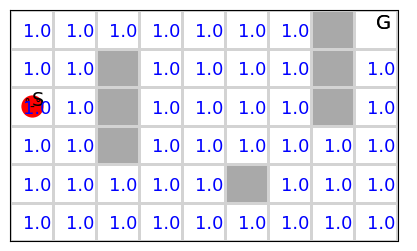

In [25]:
gw.render(underhood='V',    pause=1)

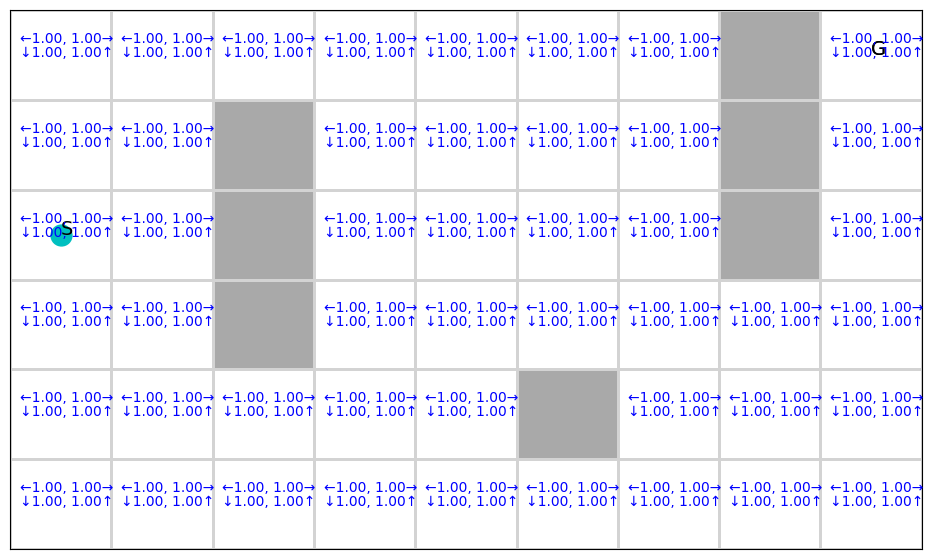

In [26]:
gw = Grid(style='maze',figsize=(40, 7))
gw.render(underhood='Q')

Note that the above is due to  plt.text('←') function which is a slow function for the display.

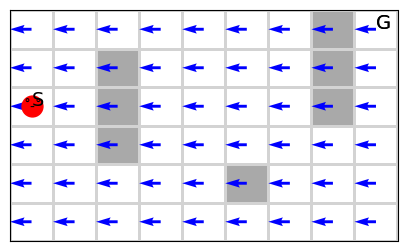

In [27]:
gw = Grid(style='maze')
gw.render(underhood='maxQ', pause=1)

Note that the above arrows are due to the plt.quiver() function and **not** the slower plt.text('←') function. 

## Visualisation for a specialist Grids

In [28]:
class Grid(Grid):
    def __init__(self, **kw):
        super().__init__(**kw)
        
        # randwalk related
        self.letters = None                    # letter rep. for states
        
    #---------------------------------helper functions specific for some env and exercises----------------------
    # renders winds values on a grid
    def render_windy(self, **kw):
        for col in range(self.cols): # skipping the first and final states
            plt.text(col+.2,-.5, self.wind[col], fontsize=13, color='k')
        plt.text(6.15,1, '⬆',fontsize=60, color='lightgray')
        plt.text(6.15,4, '⬆',fontsize=60, color='lightgray')
    
    # renders a trace path on a grid
    def render_trace(self, **kw):
        poses = self.to_pos(np.array(self.trace))
        plt.plot(poses[0]-.5, poses[1]-.5, '->c')

    def render_V(self, **kw):
        super().render_V(**kw)
        if self.rows==1: self.render_letters()

    # renders all states letters' reprsentation on the grid
    def render_letters(self, **kw): # for drawing states numbers on the grid
        if self.nS>26: return
        X,Y  = self.X, self.Y
        # to reduce overhead, create the list only when render_letters is needed
        if self.letters is None: self.letters = self.letters_list() 
        for s in range(1,self.nS-1): # skipping the first and final states
            plt.text(X[s]-.5,Y[s]+.02, self.letters[s], fontsize=13, color='g')
    
    def letters_list(self, **kw):
        letters = [chr(letter) for letter in range(ord('A'),ord('A')+(self.nS-2))]
        letters.insert(0, 'G1')
        letters.append('G2')
        return letters


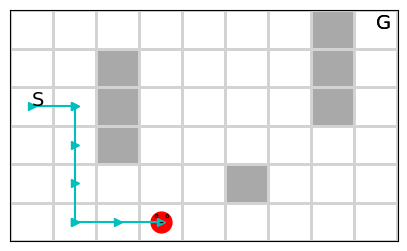

In [29]:
gw = Grid(style='maze')
for _ in range(2):gw.step(1)
for _ in range(4):gw.step(2)
for _ in range(2):gw.step(1)
    
gw.render(underhood='trace')

In [30]:
6*9-1

53

In [31]:
5//(2*10)

0

## Jumping Grid Class!
We can define a class that allows the agent to jump randomly or to a specific location in the grid without going through intermediate states. This will be used later in other lessons that deal with state representations. Here we pass jGrid to the maze function to obtain an instance of a jumping Grid class without redefining the maze.

In [32]:
# jumping grid !
class Grid(Grid):
    def __init__(self, jump=1, randjump=True, **kw):
        super().__init__(**kw)
        self.jump = jump
        self.randjump = randjump
        
    #-----------------------------------------actions related-------------------------------------------
    def step(self, a):
        jump = randint(1, min(self.jump, self.nS - self.s) +1) if self.randjump else self.jump
        if self.jump==1: return super().step(a)
            
        a = self.actions[a]*jump
        if not self.invalid(self.s, a):  
            #print('valid jump')
            self.s += a
        else: 
            #print('invalid jump')
            self.s = max(min(self.s+a, self.nS-1),0)
        
        self.trace.append(self.s)
        reward, done = self.reward() 
        return self.s_(), reward, done, {}


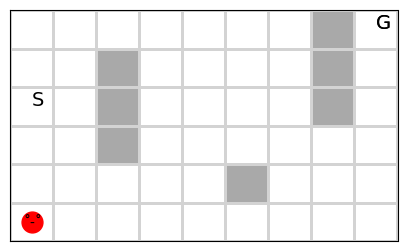

In [33]:
mz = Grid(style='maze')
mz.render()
plt.pause(1)
mz.jump = 3
mz.step(2)
mz.render()

Note how the agent jumped from start state to the bottom state directly, repeat the execution to see the effect of random jumps. You can switch this randomness off to see also the effect.

## Defining a Gridi: A Grid with Images States
Below we establish a class that will return after each step an observation which is the image of the grid instead of its state id. This is essential to be able to deal with a more general set of RL methods that are capable of learning by observing its environment instead of being given the state's id. Note that we save the images into a folder called img, so you will need to create such a folder in the folder of this notebook. If you want to change this behaviour or save images in the same folder of this notebook adjust the code accordingly.

In [34]:
import cv2
class Gridi(Grid):
    
    def __init__(self, animate=False, saveimg=False, resize=True, size=(50,84), **kw):
        super().__init__(**kw)
        self.i = 0                  # snapshot counter
        self.img = None             # snapshot image
        self.io = None              # snapshot io buffer
        self.animate = animate
        self.saveimg = saveimg
        self.resize = resize
        self.size = size

        
    # calling render__() directly is not a good idea for Gridi because s_() is calling it as well
    # calling render() allows us to turn animation/saveimg on/off
    def render(self, animate=None, saveimg=None, **kw):  
        if animate is not None: self.animate = animate 
        if saveimg is not None: self.saveimg = saveimg


    def render_image(self, saveimg):
       # prepare and scale the area that will be captured 
        if self.io is None: self.io = io.BytesIO()
        
        # scale = 0.0138888 # use this if you are using Jupyter notebooks
        scale = 0.01      # use this if you are using Jupyter Lab
        box = self.ax0.get_window_extent().transformed(mtransforms.Affine2D().scale(scale))
        
        # place frame in memory buffer then save to disk if you want
        plt.savefig(self.io, format='raw', bbox_inches=box)
        if saveimg or self.img is None: 
            plt.savefig('img/img%d.png'%self.i, bbox_inches=box); self.i+=1 
            if self.img is None: 
                self.newshape = plt.imread('img/img0.png').shape
        #try:
        # reshape the image and store current image 
        self.img = np.reshape(np.frombuffer(self.io.getvalue(), dtype=np.uint8), newshape=self.newshape)[:,:,:3]
        #except:
            #self.img = np.frombuffer(self.io.getvalue(), dtype=np.uint8)[:,:,:3]
            #print('could not convert the image')
        if self.resize:
            self.img = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)
            self.img = cv2.resize(self.img , dsize=(self.size[1],self.size[0]), interpolation=cv2.INTER_CUBIC)/255
            self.img = np.expand_dims(self.img, -1)# slightly better than  self.img = self.img[:,:,np.newaxis]
        # save only latest image to buffer and not accumulate
        self.io.seek(0) 

        
    def s_(self):
        self.render__(image=True, animate=self.animate, saveimg=self.saveimg)#, animate=self.animate)
        return self.img

Let us create a play() function to demonstrate the Gridi.

In [35]:
def play(env, steps=5):
    
    img = [env.s_()]*steps                                             # initialise and declare
    # img = np.ones((steps,*env.s_().shape),dtype=int);img[0]=env.s_() # more efficent for large steps
    for i in range(steps):
        img[i], reward, done,_ = env.step(randint(3))
        env.render()                                                   # makes no effect since s_() calls render()
    return img

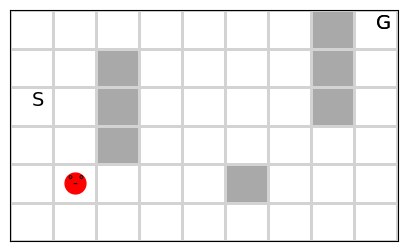

CPU times: user 421 ms, sys: 419 ms, total: 840 ms
Wall time: 321 ms


In [36]:
%time imgs0 = play(Gridi(animate=False, saveimg=True, resize=False, style='maze'))
# plt.close()
%time imgs1 = play(Gridi(animate=True, saveimg=True, resize=True, style='maze'))

In [37]:
imgs1[0].shape

(50, 84, 1)

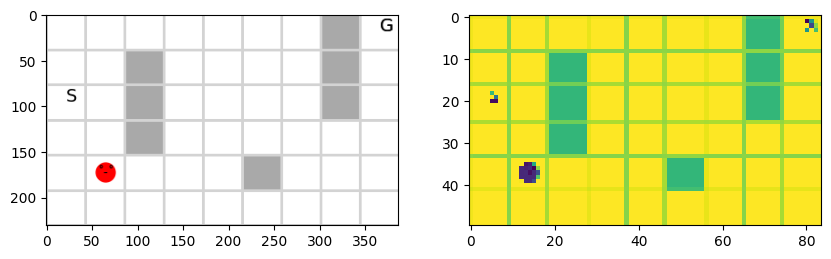

In [38]:
_, ax = plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(imgs0[4])
ax[1].imshow(imgs1[4])

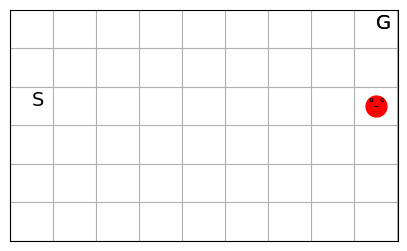

CPU times: user 5.56 s, sys: 6.91 s, total: 12.5 s
Wall time: 4.2 s


In [39]:
def test():
    gw=Gridi()#animate=False)
    for s in range(100): 
        gw.step(1)
        gw.render(image=True, animate=True)

%time test()

### Using s_() directly
We can use s_() function directly, in addition to step() function to obtain current image.

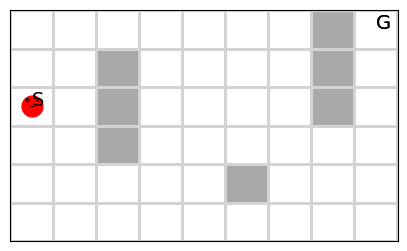

In [40]:
mz = Gridi(style='maze')
s = mz.s_()

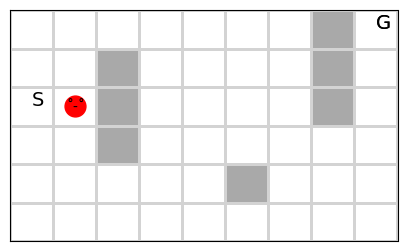

In [41]:
gw = Gridi(style='maze')
s = gw.step(1)

Note that using animate is slow because render() is being called twice unnecessarily.

(50, 84, 1)

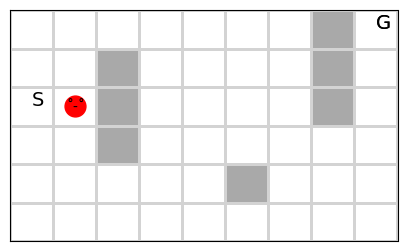

In [42]:
gw.s_().shape

Let us scan the grid and store the images on disk so that we can train a deep learning model later to extract useful features from the pixels automatically!

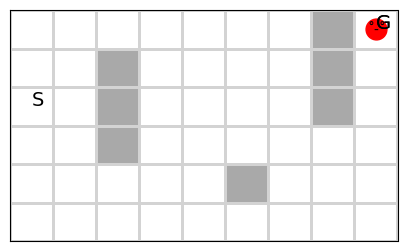

In [43]:
scan(Gridi(style='maze', saveimg=True))

## Testing Efficiency of Rendering
Let us now test the efficiency of the Grid class with respect to rendering. To do so we design a function to run some action and then render. 

In [44]:
def test_efficiency(test, n=100):
    gw=Gridi()
    gw.s=gw.s0 # reset the agent position
    # let us go right
    for s in range(n):
        gw.step(1)
        if test==0: gw.render(image=True,  animate=True)
        if test==1: gw.render(image=False, animate=True)
        if test==2: gw.render(image=True,  animate=False)
        if test==3: gw.render(image=False, animate=False)
    
    return gw

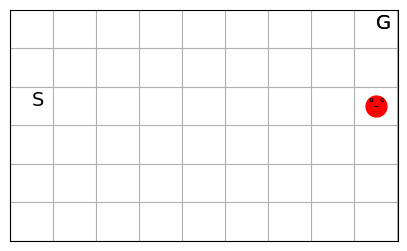

CPU times: user 5.77 s, sys: 7.06 s, total: 12.8 s
Wall time: 4.33 s


In [45]:
%time gw = test_efficiency(0)

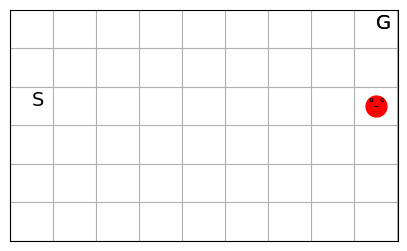

CPU times: user 5.69 s, sys: 6.91 s, total: 12.6 s
Wall time: 4.24 s
CPU times: user 2.13 s, sys: 83.7 ms, total: 2.22 s
Wall time: 2.11 s
CPU times: user 2.02 s, sys: 30.5 ms, total: 2.05 s
Wall time: 2.05 s


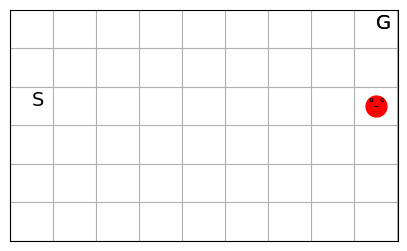

In [46]:
%time gw = test_efficiency(1)
%time gw = test_efficiency(2)
%time gw = test_efficiency(3)

Note how test3 is relatively efficient and taking little time although we are dealing images.

## Useful functions to return special types of Grids
Often we will be dealing with special types of Grid class such as grid with obstacles that constitute something like a *maze* or an agent walking on *cliff* which can occasionally fall off etc. Therefore, we define below a set of useful functions that returns these types of Grids. Also we have adopt the convention of adding a prefix to the word Grid to all classes that are derived from the Grid class. Finally, to avoid redefining the above functions we have used the Grid=Grid to pass the kind of Grid class that we meant to generate an instance of.

In [47]:
#-------------------------------suitable for control------------------------------------------------
def grid(Grid=Grid, **kw):
    return Grid(gridsize=[8, 10], s0=31, goals=[36], **kw)

def grid8(Grid=Grid, **kw): 
    return grid(Grid=Grid, nA=8, **kw)

def windy(Grid=Grid,  **kw):
    return Grid(gridsize=[7, 10], s0=30, goals=[37], style='windy', **kw)

def cliffwalk(Grid=Grid, **kw):
    return Grid(gridsize=[4, 12], s0=0,  goals=[11], style='cliff', reward='cliffwalk', **kw)

def maze(Grid=Grid, r=6, c=9, **kw):
    return Grid(gridsize=[r,c], s0=r//2*c, goals=[r*c-1], style='maze', **kw)

def maze_large(Grid=Grid, **kw):
    return maze(Grid=Grid, r=16, c=26, figsize=[25,4],**kw)

def maze8(Grid=Grid, **kw): 
    return maze(Grid=Grid, nA=8, **kw)

def mazei(Grid=Gridi, r=6, c=9, **kw):
    return Gridi(gridsize=[r,c], s0=r//2*c, goals=[r*c-1], style='maze', **kw)#figsize is made ineffective

#-------------------------------suitable for prediction------------------------------------------------
def randwalk(Grid=Grid, nS=5+2, Vstar=None, **kw):
    if Vstar is None: Vstar = np.arange(0,nS)/(nS-1)
    return Grid(gridsize=(1,nS), reward='randwalk', nA=2, goals=[0,nS-1], s0=nS//2, Vstar=Vstar, **kw)


def randwalk_(Grid=Grid, nS=19+2, Vstar=None, **kw):
    if Vstar is None: Vstar = np.arange(-(nS-1),nS,2)/(nS-1)
    return Grid(gridsize=(1,nS), reward='randwalk_', nA=2, goals=[0,nS-1], s0=nS//2, Vstar=Vstar,**kw)

Let us now try these functions that return different grid environments with visualisation.

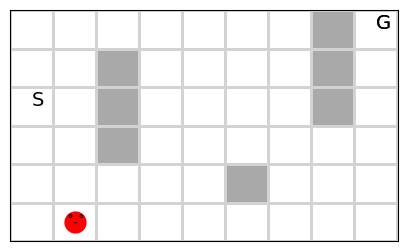

In [48]:
mzi = mazei(animate=True)
imags = play(mzi, steps=10)

## Simple grid world environment
In this environment the agent is placed in front of a goal and it just needs to go straight to find it. However to make it more difficult we ordered the actions from left to right and down to top so the agent usually picks left before right and down before top.

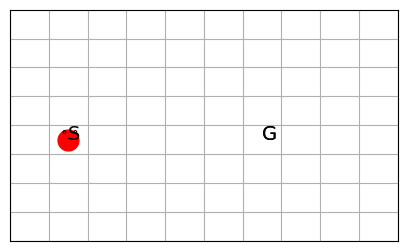

In [49]:
gw = grid()
gw.render() 

In [50]:
gw.rewards

[0, 1, 0, -100]

## Windy Environment
In a windy environment we apply a wind upwards which will push the agent 1 or 2 cells above what would be its next cell when moving in the grid. The result is that the agent will find itself pushed toward the top borders of the grid. Below we show an example.

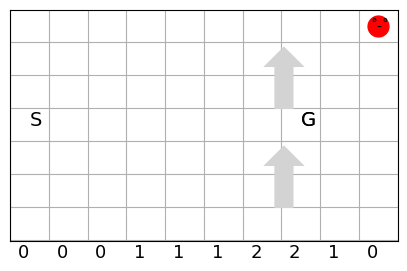

In [51]:
gw = windy()
gw.render()
gw.s0=0
wander(gw, pause=0)

In [52]:
gw.rewards

[0, 1, 0, -100]

## Maze environment
In a maze environment the agent is supposed to go form a start position to a goal position. On the way there are some obstacles that block the agent path and the goal is almost hidden in the top corner so that it is not readily accessible by the agent.

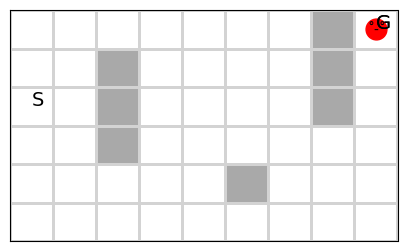

In [53]:
wander(gw=Grid(style='maze'))

## Random walk environment
In a random walk environment we simply allow the agent to flip a coin and accordingly either go left or right. The environment has two goals one to the right which yields a positive reward of 1 and one to the left which yields no reward or a negative reward, all intermediate states have rewards of 0. Below we show a visualisation of this environment.

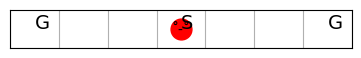

In [54]:
rw = randwalk()
rw.render()

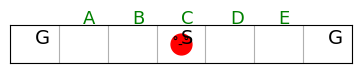

In [55]:
rw.render(underhood='letters')

The rewards array is different that the *set* of possible rewards that we will use later. Observe the difference in the below.

In [56]:
rw.rewards

[0, 0, 1, 0]

In [57]:
rw.rewards_set()

array([0, 1])

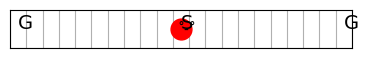

In [58]:
rw = randwalk_()
rw.render()

In [59]:
print(rw.rewards)
print(rw.rewards_set())

[0, -1, 1, 0]
[ 0  1 -1]


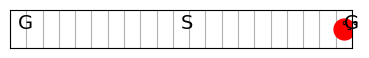

In [60]:
wander(rw)

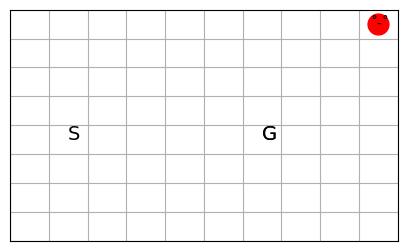

In [61]:
gw8 = grid8()
gw8.s = 50
wander(gw=gw8, pause=0)

Let us now visualise a random policy. This policy will not be useful of course for the agent to achieve its goal but it will show us how to move from a chaotic policy to an optimal one.

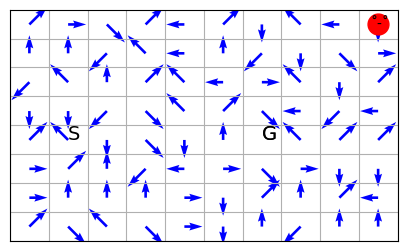

In [62]:
π=np.random.randint(gw8.nA, size=gw8.nS)
gw8.render(underhood='π', π=π)

## Cliff walking environment
In a cliff walking environment the agent needs to go purposely from a start position to a goal state. In between there is a cliff edge cells that if the agent steps into it fall off and reset into its start position.

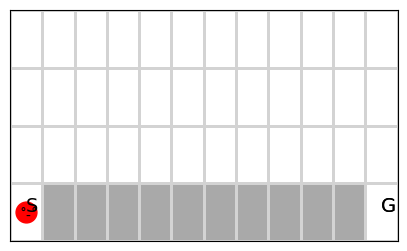

In [63]:
cw = cliffwalk()
cw.render()

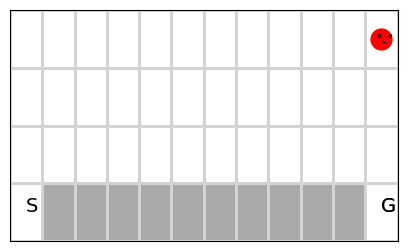

In [64]:
wander(cw, pause=0)

## Grid class misuse

The Grid class is not perfect by any means, but we made enough effort to make it work for *our purposes* and it is not well-protected against hostile usage. For example, when we use the render with underhood ='letters' for a 2-d grid it will not make sense because it is intended for a 1-d random walk problem. See below

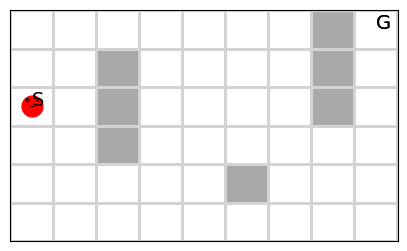

In [65]:
gw = Grid(style='maze')
gw.render(underhood='letters', pause=1)

Likewise, jumping is not protected against invalid moves.

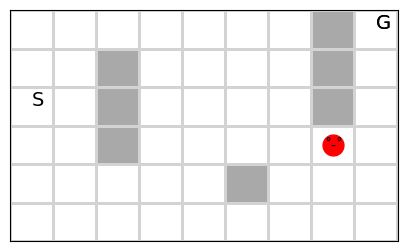

In [66]:
mz = maze(Grid)
mz.render()
plt.pause(3)
mz.jump = 3
mz.step(0)
mz.render()

## Conclusion
In this lesson, we covered a set of basic grid world environments that we will utilise in other lessons. You do not necessarily need to understand how the grid is programmatically built, but you need to understand how it operates.!

## Your turn
1. try to manually create a policy that will help the agent to reach its goal from any cell in the grid, use a simple 3x2 grid
2. try increase the grid size and see if you can come up with a policy function that will scale up consistently when we increase the grid size.

[Back to TOC](IntroductionTOC.ipynb)

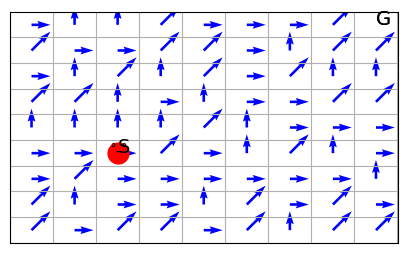

In [67]:
n_rows = 9
n_cols = 9
s0 = np.random.randint(n_rows*n_cols)
gw = Grid(gridsize=[n_rows, n_cols], s0=s0, nA=8)

p = [0, .4, 0, .2, 0, 0 , 0, .4]

π=np.array([choice(np.arange(len(p)), p=p) for i in range(n_rows*n_cols)])
gw.render(underhood='π', π=π)


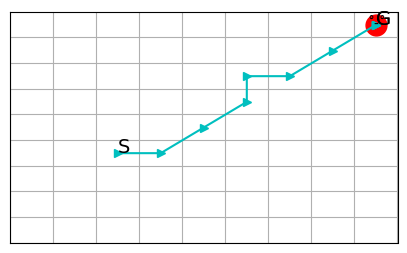

In [68]:
for i in range(10):
    π=np.array([choice(np.arange(len(p)), p=p) for i in range(n_rows*n_cols)])
    print(gw.s_())
    gw.step(π[gw.s_()])

gw.render(underhood='trace')    